# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df_women = pd.read_csv('ebay_womens_perfume.csv')
df_men = pd.read_csv('ebay_mens_perfume.csv')

df_women['target'] = 'Women'
df_men['target'] = 'Men'

df = pd.concat([df_women, df_men], ignore_index=True)
print("Data Shape:", df.shape)
df.head()

Data Shape: (2000, 11)


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,target
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.0,2 available / 393 sold,393.0,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States",Women
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong",Women
2,PRADA,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.0,More than 10 available / 35 sold,35.0,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States",Women
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.0,More than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong",Women
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.0,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States",Women


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

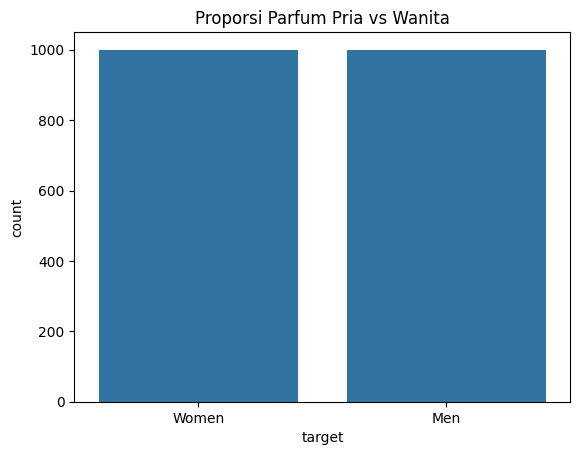


Statistik Harga:
          count      mean        std   min    25%    50%    75%     max
target                                                                
Men     1000.0  46.48120  35.527862  3.00  22.99  35.71  59.00  259.09
Women   1000.0  39.89298  29.072186  1.99  20.70  32.99  49.99  299.99

Missing Values:
 brand                  2
title                  0
type                   5
price                  0
priceWithCurrency      0
available            242
availableText         11
sold                  22
lastUpdated          126
itemLocation           0
target                 0
dtype: int64


In [3]:
sns.countplot(x='target', data=df)
plt.title('Proporsi Parfum Pria vs Wanita')
plt.show()

print("\nStatistik Harga:\n", df.groupby('target')['price'].describe())

print("\nMissing Values:\n", df.isnull().sum())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
cols_to_drop = ['title', 'priceWithCurrency', 'availableText', 'lastUpdated', 'itemLocation']
df_clean = df.drop(columns=cols_to_drop)

df_clean['sold'] = df_clean['sold'].fillna(0)
df_clean['available'] = df_clean['available'].fillna(df_clean['available'].median())

df_clean['type'] = df_clean['type'].str.lower().str.strip().fillna('unknown')
df_clean['brand'] = df_clean['brand'].str.lower().str.strip().fillna('unknown')

le = LabelEncoder()
df_clean['type'] = le.fit_transform(df_clean['type'])
df_clean['brand'] = le.fit_transform(df_clean['brand'])
df_clean['target'] = df_clean['target'].map({'Women': 0, 'Men': 1})

print("Info dataset setelah preprocessing:")
print(df_clean.info())

df_clean.to_csv('perfume_cleaned.csv', index=False)

Info dataset setelah preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   brand      2000 non-null   int64  
 1   type       2000 non-null   int64  
 2   price      2000 non-null   float64
 3   available  2000 non-null   float64
 4   sold       2000 non-null   float64
 5   target     2000 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 93.9 KB
None
